1.Fist five rows of the dataset:
    Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  

2.Statistical summary of the dataset:
              Age  Years of Experience         Salary
count  373.000000           369.000000     373.000000
mean    37.431635            10.092141  100577.345845
std      7.069073             6.556375   48240.013482
min     23.000000             0.000000     350.000000
25%     31.000000             4.000000   55000.000000
50%     36.000000             9.000000   95000.000000
75%     44.0000

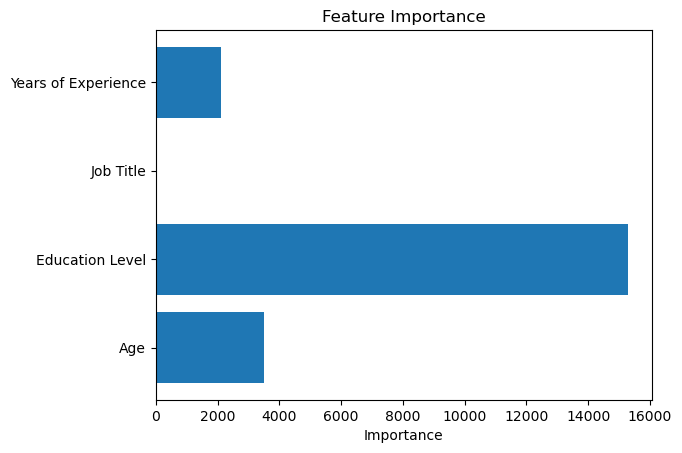

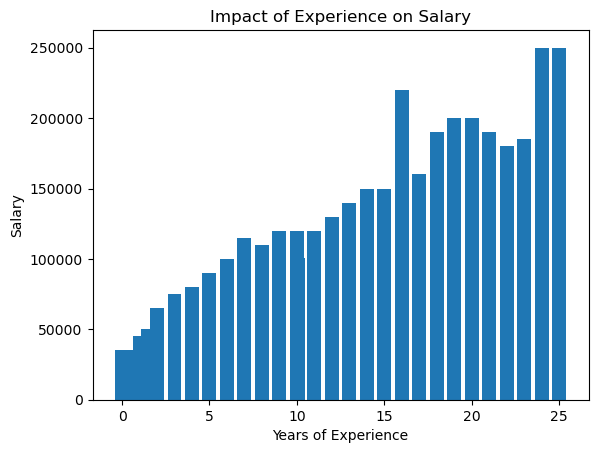

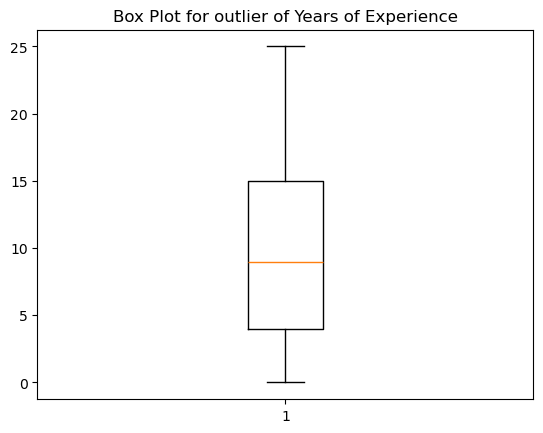

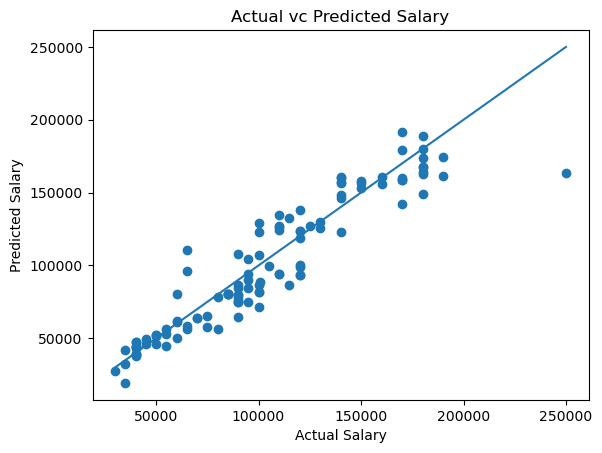

                          Age  Education Level  Job Title  \
Age                  1.000000         0.562279   0.114385   
Education Level      0.562279         1.000000   0.109063   
Job Title            0.114385         0.109063   1.000000   
Years of Experience  0.974039         0.586705   0.095788   
Salary               0.922335         0.669878   0.135349   

                     Years of Experience    Salary  
Age                             0.974039  0.922335  
Education Level                 0.586705  0.669878  
Job Title                       0.095788  0.135349  
Years of Experience             1.000000  0.924717  
Salary                          0.924717  1.000000  


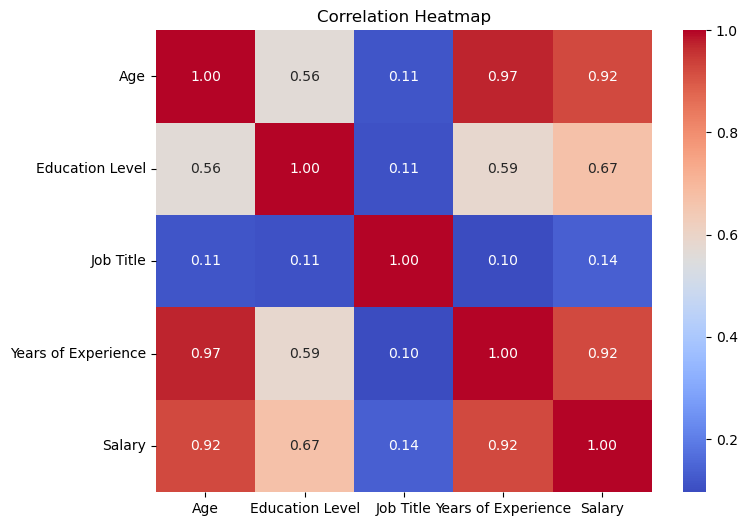


MAE: 12034.091354087172

MSE: 274212083.9461173

RMSE: 16559.35034794896

R2 Score: 0.8728930905379684


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv(r"C:\Student_salary_prediction\Student_Salary_prediction.csv")
print("1.Fist five rows of the dataset:")
print(df.head())
print("\n2.Statistical summary of the dataset:")
print(df.describe())
print("\n3.Number of null values in each column:")
print(df.isnull().sum())

#Fill missing values 
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Education Level'] = df['Education Level'].fillna(df['Education Level'].mode()[0])
df['Job Title'] = df['Job Title'].fillna(df['Job Title'].mode()[0])
df['Years of Experience'] = df['Years of Experience'].fillna(df['Years of Experience'].mean())
df['Salary'] = df['Salary'].fillna(df['Salary'].mean())

#Encoding(from categorical to numerical data)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Education Level'] = le.fit_transform(df['Education Level'])
df['Job Title'] = le.fit_transform(df['Job Title'])
print("\n4.Last five rows after encoding:")
print(df.tail())

#Creating independent and dependent variables 
X = df[['Age', 'Education Level', 'Job Title', 'Years of Experience']]         #independent variable
Y = df['Salary']                                                               #dependent variable---

#Splitting the dataset into training and testing
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

#Calling the model
model = LinearRegression()
model.fit(X_train,Y_train)
print("\n5.Intercept:",model.intercept_)
print("\n6.Coefficients:",model.coef_)
Y_pred = model.predict(X_test)

#Coefficients
importance = model.coef_

#create dataframe
feature_importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':importance
})
print("\n7.Importance of features/columns:")
print(feature_importance)

#Plotting graph for importance of features
plt.barh(feature_importance['Feature'],feature_importance['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.show()

#Plotting  Bar graph between Experience and salary
plt.bar(df['Years of Experience'], df['Salary'])
plt.title("Impact of Experience on Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

# Box Plot
plt.boxplot(df['Years of Experience'])
plt.title("Box Plot for outlier of Years of Experience")
plt.show()

#plotting Scatter graph for actual and predicted salary
plt.scatter(Y_test,Y_pred)
plt.plot([Y_test.min(),Y_test.max()],
        [Y_test.min(),Y_test.max()])
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Actual vc Predicted Salary')
plt.show()

#Calculating and plotting correlation matrix
corr_matrix = df[['Age','Education Level','Job Title','Years of Experience','Salary']].corr()
print(corr_matrix)
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', fmt = ".2f")
plt.title("Correlation Heatmap")
plt.show()

#Calculating metrics
mae = mean_absolute_error(Y_test,Y_pred)
mse = mean_squared_error(Y_test,Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test,Y_pred)
print("\nMAE:",)
print("\nMSE:",mse)
print("\nRMSE:",rmse)
print("\nR2 Score:",r2)